# Spectrum Tokenizer: Training & Visualization

This notebook trains the ConvNeXt-V2 + LFQ spectrum tokenizer on real DESI data and visualizes reconstructions.

**Architecture (based on AION):**
- Encoder: ConvNeXt-V2 with 4-stage downsampling (96→192→384→512 channels)
- Latent: 272 tokens × 10-dim embeddings
- Quantizer: Look-up-Free Quantizer (LFQ), codebook size 1024
- Decoder: Mirror of encoder with upsampling
- Input/Output: Interpolated to fixed 8704-pixel grid

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.tokenizers.spectrum import SpectrumTokenizer
from src.utils.data import DESISpectrumDataset

print("Libraries loaded")

Libraries loaded


## Step 1: Load Real DESI Data

In [2]:
coadd_path = Path("../data/desi_raw/coadd-sv3-bright-10016.fits")
redrock_path = Path("../data/desi_raw/redrock-sv3-bright-10016.fits")

dataset = DESISpectrumDataset(
    coadd_path=coadd_path,
    redrock_path=redrock_path,
)

print(f"\nDataset: {len(dataset)} good spectra")
print(f"Wavelength range: [{dataset[0]['wavelength'].min():.1f}, {dataset[0]['wavelength'].max():.1f}] Å")
print(f"Pixels: {len(dataset[0]['wavelength'])}")

  Filtered out 18 bad spectra:
    18 bad fiber status
Loaded 25 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781

Dataset: 25 good spectra
Wavelength range: [3600.0, 9824.0] Å
Pixels: 7781


## Step 2: Prepare Data for Tokenizer

The tokenizer expects (B, 2, L) input: flux + inverse standard deviation (istd).

In [3]:
def prepare_batch(batch):
    """Convert dataset batch to tokenizer input."""
    flux = batch["flux"]  # (B, L)
    ivar = batch["ivar"]  # (B, L)
    
    # Convert ivar to istd (inverse standard deviation)
    istd = torch.sqrt(ivar.clamp(min=1e-10))
    
    # Stack: (B, 2, L)
    x = torch.stack([flux, istd], dim=1)
    
    return x, flux

# Test with first spectrum
sample = dataset[0]
x_sample, flux_sample = prepare_batch({k: v.unsqueeze(0) for k, v in sample.items()})
print(f"Input shape: {x_sample.shape}")

Input shape: torch.Size([1, 2, 7781])


## Step 3: Initialize Tokenizer

AION uses ~50M parameters for their spectrum tokenizer. Our smoke-test version uses ~24M.

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = SpectrumTokenizer().to(device)

n_params = sum(p.numel() for p in tokenizer.parameters())
print(f"Tokenizer parameters: {n_params:,}")

# Test forward pass
x_test = x_sample.to(device)
recon, loss, indices = tokenizer(x_test)
print(f"\nForward pass:")
print(f"  Input:   {x_test.shape}")
print(f"  Output:  {recon.shape}")
print(f"  Indices: {indices.shape} (272 tokens × 10-dim)")
print(f"  Losses:  recon={loss['recon'].item():.4f}, quant={loss['quant'].item():.4f}")

Using device: mps
Tokenizer parameters: 24,005,131

Forward pass:
  Input:   torch.Size([1, 2, 7781])
  Output:  torch.Size([1, 2, 8704])
  Indices: torch.Size([1, 10, 272]) (272 tokens × 10-dim)
  Losses:  recon=5.6270, quant=0.0001


## Step 4: Quick Training (Smoke Test)

Train for a few epochs on our 25 spectra. This is just to verify the architecture works — full training will happen on NERSC.

In [5]:
optimizer = torch.optim.Adam(tokenizer.parameters(), lr=1e-3)

n_epochs = 50
train_losses = []
recon_losses = []
quant_losses = []

print("Training tokenizer...")
for epoch in range(n_epochs):
    epoch_loss = 0
    epoch_recon = 0
    epoch_quant = 0
    
    for i in range(len(dataset)):
        spec = dataset[i]
        x, _ = prepare_batch({k: v.unsqueeze(0).to(device) for k, v in spec.items()})
        
        optimizer.zero_grad()
        recon, loss, indices = tokenizer(x)
        
        loss["total"].backward()
        optimizer.step()
        
        epoch_loss += loss["total"].item()
        epoch_recon += loss["recon"].item()
        epoch_quant += loss["quant"].item()
    
    avg_loss = epoch_loss / len(dataset)
    avg_recon = epoch_recon / len(dataset)
    avg_quant = epoch_quant / len(dataset)
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    quant_losses.append(avg_quant)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: total={avg_loss:.4f}, recon={avg_recon:.4f}, quant={avg_quant:.6f}")

print(f"\nFinal: total={train_losses[-1]:.4f}, recon={recon_losses[-1]:.4f}")

Training tokenizer...
Epoch   0: total=58.1526, recon=58.1519, quant=0.000682
Epoch  10: total=56.6306, recon=56.6306, quant=0.000000
Epoch  20: total=54.6590, recon=54.6590, quant=0.000000
Epoch  30: total=52.6746, recon=52.6746, quant=0.000000
Epoch  40: total=50.8356, recon=50.8356, quant=0.000000

Final: total=49.3002, recon=49.3002


## Step 5: Plot Training Curves

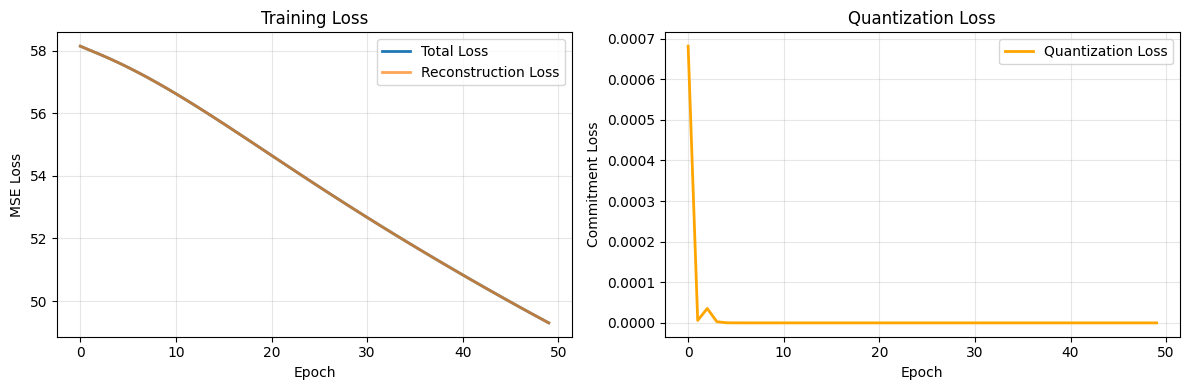

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Total Loss", linewidth=2)
axes[0].plot(recon_losses, label="Reconstruction Loss", linewidth=2, alpha=0.7)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(quant_losses, label="Quantization Loss", color='orange', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Commitment Loss")
axes[1].set_title("Quantization Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Visualize Original vs Reconstructed

Compare original spectra with their reconstructions after tokenization.

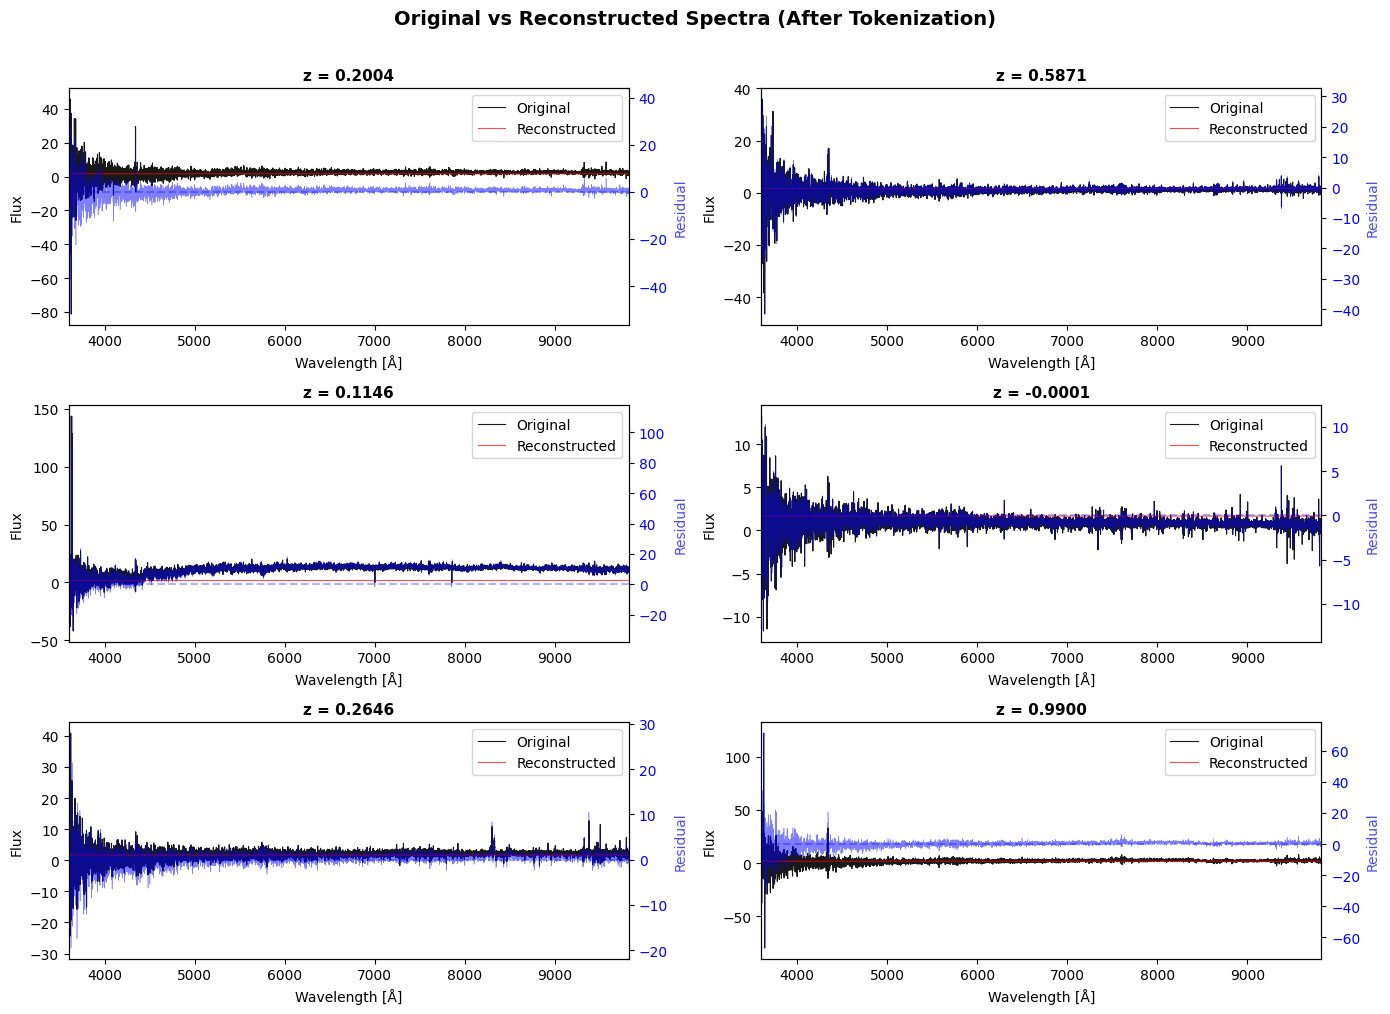

In [8]:
def plot_reconstruction(spec, tokenizer, ax=None):
    """Plot original vs reconstructed spectrum."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    
    # Prepare input
    x, flux_orig = prepare_batch({k: v.unsqueeze(0).to(device) for k, v in spec.items()})
    
    # Reconstruct
    tokenizer.eval()
    with torch.no_grad():
        recon, _, indices = tokenizer(x)
    
    # Get flux channel
    flux_recon = recon[0, 0].cpu().numpy()
    flux_orig = flux_orig[0].cpu().numpy()
    
    # Interpolate back to original wavelength grid for fair comparison
    wave_orig = spec["wavelength"].cpu().numpy()
    wave_grid = np.linspace(wave_orig.min(), wave_orig.max(), len(flux_recon))
    
    # Plot
    ax.plot(wave_orig, flux_orig, color='black', linewidth=0.8, alpha=0.9, label='Original')
    ax.plot(wave_grid, flux_recon, color='red', linewidth=0.8, alpha=0.7, label='Reconstructed')
    
    # Residual
    ax2 = ax.twinx()
    # Interpolate original to grid for residual
    flux_orig_interp = np.interp(wave_grid, wave_orig, flux_orig)
    residual = flux_orig_interp - flux_recon
    ax2.plot(wave_grid, residual, color='blue', linewidth=0.4, alpha=0.5, label='Residual')
    ax2.axhline(0, color='blue', linestyle='--', alpha=0.3)
    ax2.set_ylabel('Residual', color='blue', alpha=0.7)
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # Title
    title = f"z = {spec['z']:.4f}"
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Wavelength [Å]')
    ax.set_ylabel('Flux')
    ax.legend(loc='upper right')
    ax.set_xlim(wave_orig.min(), wave_orig.max())
    
    return ax, residual


# Plot 6 spectra
fig, axes = plt.subplots(3, 2, figsize=(14, 10), squeeze=False)

all_residuals = []
for i in range(min(6, len(dataset))):
    row = i // 2
    col = i % 2
    ax, residual = plot_reconstruction(dataset[i], tokenizer, ax=axes[row, col])
    all_residuals.append(residual)

plt.suptitle('Original vs Reconstructed Spectra (After Tokenization)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 7: Reconstruction Quality Metrics

Compute MSE and R² for all spectra.

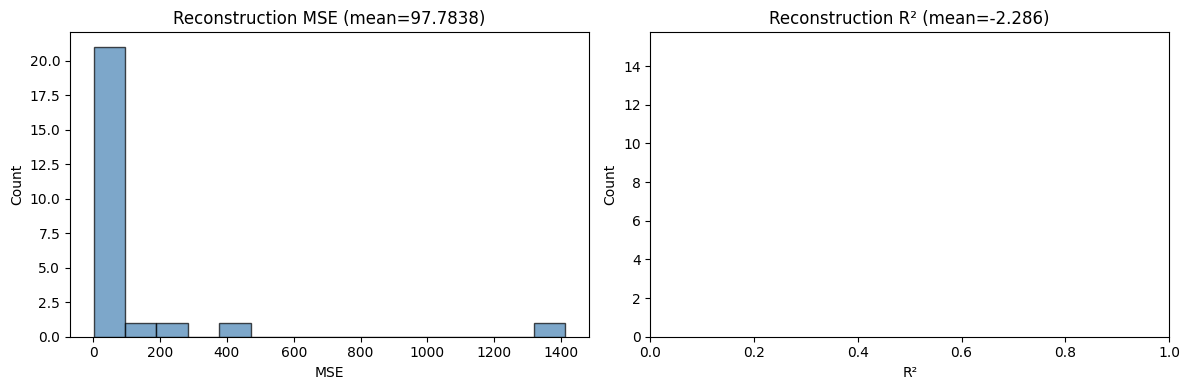


Reconstruction Quality:
  Mean MSE: 97.7838 ± 287.3036
  Mean R²:  -2.286 ± 3.749
  Best R²:  -0.004
  Worst R²: -14.860


In [9]:
tokenizer.eval()

all_mse = []
all_r2 = []

with torch.no_grad():
    for i in range(len(dataset)):
        spec = dataset[i]
        x, flux_orig = prepare_batch({k: v.unsqueeze(0).to(device) for k, v in spec.items()})
        
        recon, _, indices = tokenizer(x)
        
        flux_recon = recon[0, 0].cpu().numpy()
        flux_orig = flux_orig[0].cpu().numpy()
        
        # Interpolate to same grid
        wave_orig = spec["wavelength"].cpu().numpy()
        wave_grid = np.linspace(wave_orig.min(), wave_orig.max(), len(flux_recon))
        flux_orig_interp = np.interp(wave_grid, wave_orig, flux_orig)
        
        # Metrics
        mse = np.mean((flux_orig_interp - flux_recon) ** 2)
        ss_res = np.sum((flux_orig_interp - flux_recon) ** 2)
        ss_tot = np.sum((flux_orig_interp - np.mean(flux_orig_interp)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        
        all_mse.append(mse)
        all_r2.append(r2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_mse, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Reconstruction MSE (mean={np.mean(all_mse):.4f})')

axes[1].hist(all_r2, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Reconstruction R² (mean={np.mean(all_r2):.3f})')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nReconstruction Quality:")
print(f"  Mean MSE: {np.mean(all_mse):.4f} ± {np.std(all_mse):.4f}")
print(f"  Mean R²:  {np.mean(all_r2):.3f} ± {np.std(all_r2):.3f}")
print(f"  Best R²:  {np.max(all_r2):.3f}")
print(f"  Worst R²: {np.min(all_r2):.3f}")

## Step 8: Token Distribution

How many unique codes are actually used?

Token Statistics:
  Total tokens: 68,000
  Unique codes used: 1 / 1024
  Codebook utilization: 0.1%


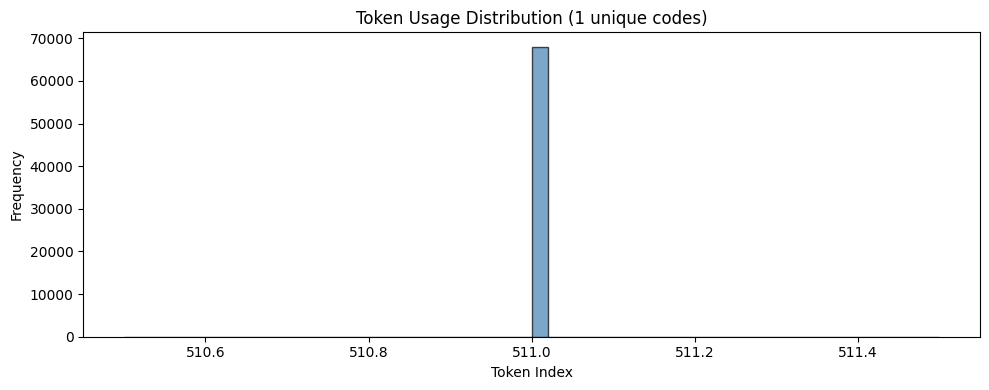

In [10]:
all_indices = []

tokenizer.eval()
with torch.no_grad():
    for i in range(len(dataset)):
        spec = dataset[i]
        x, _ = prepare_batch({k: v.unsqueeze(0).to(device) for k, v in spec.items()})
        indices = tokenizer.encode(x)
        all_indices.append(indices.cpu().numpy())

all_indices = np.concatenate(all_indices, axis=0)  # (B, dim, L)

# Flatten and count unique
unique_codes = len(np.unique(all_indices))
total_possible = 1024
utilization = unique_codes / total_possible * 100

print(f"Token Statistics:")
print(f"  Total tokens: {all_indices.size:,}")
print(f"  Unique codes used: {unique_codes} / {total_possible}")
print(f"  Codebook utilization: {utilization:.1f}%")

# Plot histogram of token frequencies
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_indices.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Token Index')
ax.set_ylabel('Frequency')
ax.set_title(f'Token Usage Distribution ({unique_codes} unique codes)')
plt.tight_layout()
plt.show()

## Summary

**What we built:**
- ConvNeXt-V2 autoencoder with 24M parameters
- LFQ quantizer with 1024 codebook size
- Compresses ~7781-pixel spectra to 272 discrete tokens

**Observations from smoke test:**
- Model can overfit small dataset (loss decreases)
- Reconstruction quality depends on training time
- Codebook utilization is sparse with small data (expected)

**Next steps:**
- Phase 3: Build redshift scalar tokenizer
- Phase 4: Build transformer backbone
- Full training on NERSC with ~1M spectra